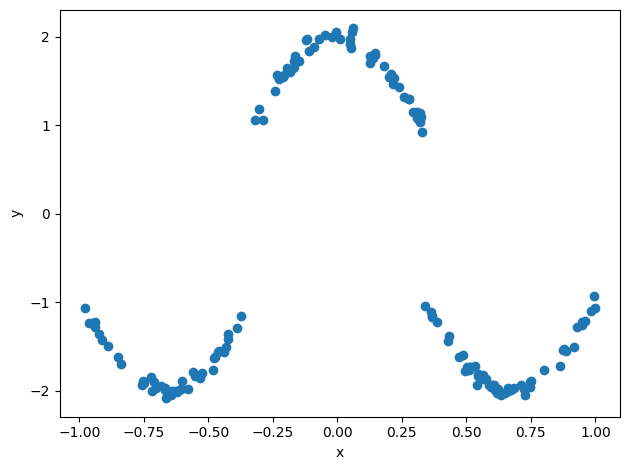

In [4]:
import matplotlib.pyplot as plt
import torch

torch.manual_seed(1)

num_experts = 3
num_training_points = 150

x_min = -1.0
x_max = 1.0

X = x_min + (x_max - x_min) * torch.rand(
    num_training_points, 1
)

# Three equally wide regions:
# [-1, -1/3), [-1/3, 1/3), [1/3, 1]
edges = torch.linspace(x_min, x_max, num_experts + 1)

# Region index: 0, 1, or 2
region = torch.bucketize(
    X.squeeze(-1),
    edges[1:-1],
)

# Convert the global x coordinate to a local coordinate in [0, 1]
left_edges = edges[region]
right_edges = edges[region + 1]

local_x = (
    X.squeeze(-1) - left_edges
) / (
    right_edges - left_edges
)

# Vertical baseline of each half-sine
offsets = torch.tile(torch.tensor([-1, 1]), (-(num_experts // -2) ,))

# Amplitude of each half-sine
amplitudes = torch.tile(torch.tensor([-1, 1]), (-(num_experts // -2) ,))

# Noise standard deviation
noise_std = 0.05

Y = (
    offsets[region]
    + amplitudes[region] * torch.sin(torch.pi * local_x)
    + noise_std * torch.randn(num_training_points)
).unsqueeze(-1)

# Plot synthetic data
_, ax = plt.subplots()
ax.scatter(X, Y)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
